# Ideogram 4: Interactive Playground

A fully parameterized notebook for running **Ideogram 4** locally.
All inference runs on your local GPU using weights downloaded once from
Hugging Face — no API calls are made during image generation.

## Model weights

On the **first run** of the *Load pipeline* cell, `huggingface_hub` downloads
the weights to your local HF cache (`~/.cache/huggingface/hub/` by default).
This is a one-time download of **~12–15 GB**. All subsequent runs load from disk — no internet needed.

| Variant | HF repo | Device | VRAM | Notes |
|---------|---------|--------|------|------|
| **nf4** | `ideogram-ai/ideogram-4-nf4` | CUDA only | ~10 GB | Recommended for RTX 4090 |
| **fp8** | `ideogram-ai/ideogram-4-fp8` | any (CUDA/CPU) | ~13 GB | Use if no CUDA |


---

**Run order:** execute cells top-to-bottom once per session.
The *Load pipeline* cell is heavy — run it once and reuse `pipe` for all subsequent generations.

## Device & quantization detection

```
# Auto-picks the best available device and the matching weight variant:
#   CUDA  → nf4 (ideogram-ai/ideogram-4-nf4)  — bitsandbytes 4-bit
#   other → fp8 (ideogram-ai/ideogram-4-fp8)  — weight-only float8
#
# Override DEVICE or QUANTIZATION below if you want to force a specific choice.
```

In [1]:
import os
import torch
from pathlib import Path
from huggingface_hub import constants as hf_constants

In [2]:
def _default_device() -> str:
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


DEVICE = _default_device()
QUANTIZATION = 'nf4' if DEVICE == 'cuda' else 'fp8'

WEIGHTS_REPOS = {
    'nf4': 'ideogram-ai/ideogram-4-nf4',
    'fp8': 'ideogram-ai/ideogram-4-fp8',
}
WEIGHTS_REPO = WEIGHTS_REPOS[QUANTIZATION]
print(WEIGHTS_REPO)

ideogram-ai/ideogram-4-nf4


## Hardware summary

In [3]:
print(f'Device      : {DEVICE}')
print(f'Quantization: {QUANTIZATION}')
print(f'Weights repo: {WEIGHTS_REPO}  (HuggingFace — downloaded once, then local)')
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {props.total_memory / 1e9:.1f} GB')
    print(f'CUDA        : {torch.version.cuda}')

Device      : cuda
Quantization: nf4
Weights repo: ideogram-ai/ideogram-4-nf4  (HuggingFace — downloaded once, then local)
GPU         : NVIDIA GeForce RTX 4090
VRAM        : 25.8 GB
CUDA        : 13.0


## HF cache status

In [4]:
hf_cache = Path(os.environ.get('HF_HOME', hf_constants.HF_HOME)) / 'hub'
print(f'\nHF cache    : {hf_cache}')

# Check whether each variant is already downloaded
for quant, repo in WEIGHTS_REPOS.items():
    cache_dir = hf_cache / f'models--{repo.replace("/", "--")}'
    if cache_dir.exists():
        size_gb = sum(f.stat().st_size for f in cache_dir.rglob('*') if f.is_file()) / 1e9
        marker = '✅ cached' if quant == QUANTIZATION else '   cached'
        print(f'{marker} {repo}  ({size_gb:.1f} GB on disk)')
    else:
        marker = '⬇ will download' if quant == QUANTIZATION else '   not downloaded'
        print(f'{marker} {repo}')


HF cache    : /mnt/d/HF_CACHE/hub
✅ cached ideogram-ai/ideogram-4-nf4  (32.2 GB on disk)
   not downloaded ideogram-ai/ideogram-4-fp8


In [5]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


## Load pipeline

- First run: downloads weights from HF to ~/.cache/huggingface/hub/ (~12-15 GB).
- Subsequent runs: loads directly from the local cache — no internet needed.

In [6]:
from ideogram4 import Ideogram4Pipeline, Ideogram4PipelineConfig

print(f'Loading pipeline from: {WEIGHTS_REPO}')
print('(First run downloads ~12-15 GB; subsequent runs load from local cache)')
print()

pipe = Ideogram4Pipeline.from_pretrained(
    config=Ideogram4PipelineConfig(weights_repo=WEIGHTS_REPO),
    device=DEVICE,
    dtype=torch.bfloat16,
)

print()
print('Pipeline loaded. All weights are on local disk — ready to generate.')

Loading pipeline from: ideogram-ai/ideogram-4-nf4
(First run downloads ~12-15 GB; subsequent runs load from local cache)



[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/749 [00:00<?, ?it/s]


Pipeline loaded. All weights are on local disk — ready to generate.


## Parameter Control Panel

The cell below renders interactive widgets for every `pipe(...)` parameter.
Pick a **Preset** to auto-fill the sampler settings, or select **Custom** to
tune each knob manually.

| Parameter | Description | Valid range |
|-----------|-------------|-------------|
| **Width / Height** | Output resolution | 256–2048 px, multiples of 16; max aspect 6:1 |
| **Preset** | Bundles steps + CFG schedule + mu + std | see table below |
| **Num steps** | More = higher quality, slower | 1–128 |
| **CFG scale** | Constant guidance weight (used when no schedule) | 1–20 |
| **mu** | Logit-normal schedule mean | −2 to 2 |
| **std** | Logit-normal schedule std | 0.1–3.0 |
| **Seed** | Reproducibility seed (−1 = random) | any int |
| **Guidance schedule** | Per-step guidance weights (comma-sep, length = num_steps) | floats |

**Preset reference:**

| Preset | Steps | mu | std | Notes |
|--------|-------|----|-----|-------|
| `V4_QUALITY_48` | 48 | 0.0 | 1.5 | Best quality (default) |
| `V4_DEFAULT_20` | 20 | 0.0 | 1.75 | Good speed/quality trade-off |
| `V4_TURBO_12` | 12 | 0.5 | 1.75 | Fastest |
| `Custom` | — | — | — | Full manual control |

## Interactive parameter panel

In [7]:
import ipywidgets as widgets
from ipywidgets import (
    IntSlider, FloatSlider, IntText, Checkbox,
    Dropdown, Textarea, VBox, HBox, HTML, Label,
)
from ideogram4 import PRESETS

# ── Resolution ────────────────────────────────────────────────────────────────
w_width = IntSlider(
    value=1536, min=256, max=2048, step=16,
    description='Width:', style={'description_width': '80px'},
    layout=widgets.Layout(width='380px'),
)
w_height = IntSlider(
    value=1024, min=256, max=2048, step=16,
    description='Height:', style={'description_width': '80px'},
    layout=widgets.Layout(width='380px'),
)

# ── Preset selector ───────────────────────────────────────────────────────────
PRESET_NAMES = sorted(PRESETS.keys()) + ['Custom']
w_preset = Dropdown(
    options=PRESET_NAMES, value='V4_QUALITY_48',
    description='Preset:', style={'description_width': '80px'},
    layout=widgets.Layout(width='300px'),
)

# ── Sampler knobs (auto-filled and locked when a preset is active) ────────────
w_num_steps = IntSlider(
    value=48, min=1, max=128, step=1,
    description='Num steps:', style={'description_width': '100px'},
    layout=widgets.Layout(width='380px'), disabled=True,
)
w_guidance_scale = FloatSlider(
    value=7.0, min=1.0, max=20.0, step=0.1,
    description='CFG scale:', style={'description_width': '100px'},
    layout=widgets.Layout(width='380px'), disabled=True,
    readout_format='.1f',
)
w_mu = FloatSlider(
    value=0.0, min=-2.0, max=2.0, step=0.05,
    description='mu:', style={'description_width': '100px'},
    layout=widgets.Layout(width='380px'), disabled=True,
    readout_format='.2f',
)
w_std = FloatSlider(
    value=1.5, min=0.1, max=3.0, step=0.05,
    description='std:', style={'description_width': '100px'},
    layout=widgets.Layout(width='380px'), disabled=True,
    readout_format='.2f',
)

# ── Misc ──────────────────────────────────────────────────────────────────────
w_seed = IntText(
    value=42, description='Seed:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='200px'),
)
w_raise = Checkbox(
    value=True, description='Raise on caption issues',
    layout=widgets.Layout(width='260px'),
)

# ── Per-step guidance schedule ────────────────────────────────────────────────
w_guidance_schedule = Textarea(
    value='',
    placeholder=(
        'Optional: comma-separated floats, length must equal num_steps. '
        'Leave empty to use CFG scale as a constant. '
        'Auto-filled when a preset is selected.'
    ),
    description='Schedule:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='100%', height='70px'),
    disabled=True,
)


# ── Preset ↔ widget wiring ────────────────────────────────────────────────────
def on_preset_change(change):
    preset_name = change['new']
    if preset_name == 'Custom':
        for w in (w_num_steps, w_guidance_scale, w_mu, w_std, w_guidance_schedule):
            w.disabled = False
        w_guidance_schedule.value = ''
    else:
        p = PRESETS[preset_name]
        w_num_steps.value = p.num_steps
        w_mu.value = p.mu
        w_std.value = p.std
        w_guidance_schedule.value = ','.join(str(g) for g in p.guidance_schedule)
        for w in (w_num_steps, w_guidance_scale, w_mu, w_std, w_guidance_schedule):
            w.disabled = True

w_preset.observe(on_preset_change, names='value')
on_preset_change({'new': w_preset.value})  # initialise with default preset


# ── Assemble panel ────────────────────────────────────────────────────────────
panel = VBox([
    HTML('<h3 style="margin:0 0 8px">Generation Parameters</h3>'),
    HTML('<b>Resolution</b>'),
    HBox([w_width, w_height]),
    HTML('<b>Sampler preset</b>'),
    HBox([w_preset]),
    HTML('<b>Sampler knobs</b> (editable in Custom mode)'),
    HBox([w_num_steps, w_guidance_scale]),
    HBox([w_mu, w_std]),
    HTML('<b>Misc</b>'),
    HBox([w_seed, w_raise]),
    HTML('<b>Per-step guidance schedule</b> (auto-filled by preset; editable in Custom mode)'),
    w_guidance_schedule,
], layout=widgets.Layout(border='1px solid #ccc', padding='12px', border_radius='6px'))

panel

In [8]:
# ── read_params() + generate() helpers ───────────────────────────────────────

import os
import time
import json
from datetime import datetime
from IPython.display import display


def read_params() -> dict:
    """
    Read the current widget values into a kwargs dict ready for pipe(...).

    guidance_schedule is None when the textarea is empty (pipe then uses
    guidance_scale as a constant weight). When non-empty it is parsed as
    comma-separated floats and validated against num_steps.
    """
    schedule = None
    raw = w_guidance_schedule.value.strip()
    if raw:
        vals = [float(v.strip()) for v in raw.split(',') if v.strip()]
        if len(vals) != w_num_steps.value:
            raise ValueError(
                f'guidance_schedule has {len(vals)} values but num_steps={w_num_steps.value}. '
                f'They must match.'
            )
        schedule = vals

    seed = w_seed.value if w_seed.value >= 0 else None

    return dict(
        height=w_height.value,
        width=w_width.value,
        num_steps=w_num_steps.value,
        guidance_scale=w_guidance_scale.value,
        guidance_schedule=schedule,
        mu=w_mu.value,
        std=w_std.value,
        seed=seed,
        raise_on_caption_issues=w_raise.value,
    )


def generate(
    prompt: str,
    output_path: str | None = None,
    **overrides,
):
    """
    Generate an image from *prompt* using the current panel settings.

    Inference runs entirely on the local GPU — the loaded weights are already
    in memory; no network requests are made.

    Args:
        prompt:      Plain text or a JSON-structured caption string.
        output_path: Where to save the PNG (default: outputs/<timestamp>.png).
        **overrides: Override any parameter from read_params() for this call
                     without moving the sliders.

    Returns:
        PIL.Image
    """
    params = read_params()
    params.update(overrides)

    print('Parameters:')
    for k, v in params.items():
        if k == 'guidance_schedule' and v is not None:
            print(f'  {k}: [{v[0]}, ..., {v[-1]}] (len={len(v)})')
        else:
            print(f'  {k}: {v}')
    print('Generating (local GPU inference)...')

    t0 = time.perf_counter()
    images = pipe(
        prompt,
        height=params['height'],
        width=params['width'],
        num_steps=params['num_steps'],
        guidance_scale=params['guidance_scale'],
        guidance_schedule=params['guidance_schedule'],
        mu=params['mu'],
        std=params['std'],
        seed=params['seed'],
        raise_on_caption_issues=params['raise_on_caption_issues'],
    )
    elapsed = time.perf_counter() - t0
    steps = params['num_steps']
    print(f'Done in {elapsed:.1f}s  ({elapsed/steps:.2f}s/step)')

    img = images[0]

    if output_path is None:
        os.makedirs('outputs', exist_ok=True)
        output_path = f'outputs/image_{datetime.now():%Y%m%d_%H%M%S}.png'

    img.save(output_path)
    print(f'Saved → {output_path}')
    display(img)
    return img


print('Helpers ready: read_params() and generate() defined.')


Helpers ready: read_params() and generate() defined.


---

## Optional: Magic Prompt Expansion

Magic prompt converts a plain English sentence into the structured JSON caption
the model was trained on. **This is the only part that calls an external API.**
The actual image generation still runs locally.

Three backends are available (see `docs/prompting.md`):

| Key | Backend | Env var |
|-----|---------|----------|
| `ideogram-4-v1` | Ideogram hosted API (free, default) | `IDEOGRAM_API_KEY` |
| `claude-opus-v1` | Claude Opus 4.8 via OpenRouter | `MAGIC_PROMPT_API_KEY` |
| `claude-sonnet-v1` | Claude Sonnet 4.6 via OpenRouter | `MAGIC_PROMPT_API_KEY` |

**Skip this section entirely** if you prefer to write JSON captions directly
(like the XGBoost warehouse example below). No API key is needed for that.

In [9]:
# ── Optional: expand a plain prompt into a structured JSON caption ─────────────
# Set your API key and run this cell. Image generation still runs locally after.

import os
from ideogram4 import MAGIC_PROMPTS, aspect_ratio_from_size

# ── Config ────────────────────────────────────────────────────────────────────
MAGIC_PROMPT_MODEL  = 'ideogram-4-v1'   # or 'claude-opus-v1', 'claude-sonnet-v1'
MAGIC_PROMPT_API_KEY = os.environ.get('MAGIC_PROMPT_API_KEY') or os.environ.get('IDEOGRAM_API_KEY')
PLAIN_PROMPT = 'a golden retriever on a skateboard at sunset'

# ── Expand ────────────────────────────────────────────────────────────────────
if not MAGIC_PROMPT_API_KEY:
    print('No API key found. Set MAGIC_PROMPT_API_KEY or IDEOGRAM_API_KEY and re-run.')
else:
    aspect = aspect_ratio_from_size(w_width.value, w_height.value)
    magic  = MAGIC_PROMPTS[MAGIC_PROMPT_MODEL](api_key=MAGIC_PROMPT_API_KEY)
    print(f'Expanding via {MAGIC_PROMPT_MODEL} for aspect {aspect}...')
    expanded_caption = magic.expand(PLAIN_PROMPT, aspect_ratio=aspect)
    print('\nExpanded caption (JSON — local inference will use this):')
    print(expanded_caption)

    # ── Generate locally using the expanded caption ───────────────────────────
    # img = generate(expanded_caption, output_path='outputs/magic_prompt.png')

No API key found. Set MAGIC_PROMPT_API_KEY or IDEOGRAM_API_KEY and re-run.


## Example: Neon Ramen Alley

A hand-crafted, schema-correct JSON caption — no API key needed.

**Scene:** a rain-soaked cyberpunk night-market alley. A glowing ramen stall blazes
with multilingual neon: Japanese kanji, a price board, fluttering lanterns, steam
rising through puddles of reflected magenta and cyan light.

This example is deliberately **text-rendering heavy** to show off Ideogram 4's
ability to render legible multilingual signage inside a richly atmospheric scene.

Caption schema notes:
- `style_description` uses the **photo** branch — key order: `aesthetics → lighting → photo → medium → color_palette`
- `obj` elements: `type → bbox → desc`
- `text` elements: `type → bbox → text → desc` — literal Japanese characters are kept
  as-is (serialized with `ensure_ascii=False` so the verifier doesn't warn)
- `bbox` = `[y_min, x_min, y_max, x_max]` in normalized 0–1000 coordinates


In [10]:
import json
from ideogram4.caption_verifier import CaptionVerifier

# Key order is enforced by CaptionVerifier — Python 3.7+ dicts preserve
# insertion order, so writing keys in the right order here is sufficient.

ramen_caption = {
    'high_level_description': (
        'A cinematic wide-angle night photograph of a narrow rain-soaked cyberpunk alley '
        'in a Japanese city. A blazing ramen stall dominates the left side, its neon signs '
        'reflecting in the wet asphalt. A lone hooded customer sits at the counter under '
        'a canopy of red lanterns, steam rising from a bowl into the cold neon-lit air. '
        'Every surface glows with magenta, cyan, and amber light.'
    ),
    'style_description': {
        # photo branch — key order: aesthetics, lighting, photo, medium, color_palette
        'aesthetics': 'cyberpunk, atmospheric, neon-drenched, cinematic noir, rain-soaked reflections',
        'lighting': (
            'dominant neon uplighting in magenta and cyan from the storefront signs, '
            'warm amber spill from paper lanterns, wet asphalt reflections doubling every '
            'light source, deep shadows in the alley recesses, light rain visible as '
            'luminous streaks against the dark background'
        ),
        'photo': '18mm ultra-wide, f/2.8, 1/30s, ISO 3200, slight chromatic aberration, rain on lens',
        'medium': 'photograph',
        'color_palette': [
            '#FF2D78',  # neon magenta
            '#00F5FF',  # electric cyan
            '#FF8C00',  # warm amber lantern
            '#0A0A1A',  # deep night shadow
            '#1A0033',  # dark purple haze
            '#F0E6FF',  # white steam / haze
            '#FF4500',  # hot ramen glow
        ],
    },
    'compositional_deconstruction': {
        'background': (
            'A narrow urban alley receding into darkness, flanked by concrete walls '
            'plastered with torn posters and smaller neon signs. The ground is slick wet '
            'asphalt streaked with elongated reflections of every neon color. Mist and '
            'rain drift through the air. Power lines and hanging cables cross overhead. '
            'Far down the alley, a hazy blue-purple glow suggests more city beyond.'
        ),
        'elements': [
            # ── Ramen stall structure ─────────────────────────────────────────
            {
                'type': 'obj',
                'bbox': [120, 0, 980, 550],
                'desc': (
                    'A small traditional Japanese ramen stall with a low wooden counter, '
                    'open to the alley. The stall front is lit by its own neon tubes and '
                    'a row of red paper lanterns strung along the canopy edge. Shelves '
                    'behind the counter hold bottles, bowls, and condiment jars. The cook '
                    'is a blur of motion in the steam-filled interior. The stall canopy '
                    'is dark canvas draped with water, dripping at the edges.'
                ),
            },
            # ── Hooded customer ───────────────────────────────────────────────
            {
                'type': 'obj',
                'bbox': [380, 250, 970, 490],
                'desc': (
                    'A lone customer seated on a wooden stool at the counter, wearing a '
                    'deep navy hooded jacket with the hood up, face partially visible in '
                    'profile — young, lit from below by a warm amber glow. Both hands '
                    'wrapped around a large white ceramic ramen bowl, steam rising in '
                    'thick curls around their face. Chopsticks resting across the bowl.'
                ),
            },
            # ── Steam clouds ──────────────────────────────────────────────────
            {
                'type': 'obj',
                'bbox': [50, 180, 430, 520],
                'desc': (
                    'Dense white and pale-violet steam billowing upward from the ramen '
                    'pots on the stall, catching the neon light and glowing faintly '
                    'magenta on one side and cyan on the other, drifting lazily into '
                    'the cold alley air and mingling with the light rain.'
                ),
            },
            # ── Lantern row ───────────────────────────────────────────────────
            {
                'type': 'obj',
                'bbox': [120, 0, 310, 560],
                'desc': (
                    'A row of seven traditional red paper lanterns strung along the '
                    'underside of the stall canopy, each glowing amber-orange from '
                    'within. They sway slightly as if in a light breeze, casting '
                    'rounded warm pools of light on the counter and customer below.'
                ),
            },
            # ── Main neon sign: NEON RAMEN ────────────────────────────────────
            {
                'type': 'text',
                'bbox': [125, 20, 280, 420],
                'text': 'NEON RAMEN',
                'desc': (
                    'The primary storefront neon sign in large block capital letters, '
                    'bright hot-pink/magenta neon tubing mounted on a dark backing board. '
                    'The letters glow intensely and cast magenta halos onto the wet wall '
                    'behind them. Slight flicker effect visible on the N.'
                ),
                'color_palette': ['#FF2D78', '#FF80B0'],
            },
            # ── 24時間 (24 hours) sign ─────────────────────────────────────────
            {
                'type': 'text',
                'bbox': [135, 430, 225, 600],
                'text': '24時間',
                'desc': (
                    'A small neon sign reading "24時間" (24 hours) in electric cyan '
                    'tubing, mounted just below and to the right of the main sign. '
                    'Smaller than the main sign, the kanji and numbers glow steadily '
                    'with a bright cyan halo against the dark wall.'
                ),
                'color_palette': ['#00F5FF', '#80FAFF'],
            },
            # ── OPEN sign ─────────────────────────────────────────────────────
            {
                'type': 'text',
                'bbox': [280, 20, 375, 185],
                'text': 'OPEN',
                'desc': (
                    'A buzzing yellow-green neon OPEN sign in a rounded sans-serif '
                    'font, hanging just inside the stall entrance. Slightly flickering, '
                    'with a greenish glow spilling onto the edge of the canopy.'
                ),
                'color_palette': ['#BFFF00', '#E8FF80'],
            },
            # ── Menu board ────────────────────────────────────────────────────
            {
                'type': 'text',
                'bbox': [340, 0, 640, 200],
                'text': 'ラーメン  ¥800\n餃子     ¥500\nビール   ¥600',
                'desc': (
                    'A hand-written chalk menu board mounted on the side wall of the '
                    'stall, listing three items in Japanese with yen prices in white '
                    'and yellow chalk on a dark slate surface. The kanji are neat but '
                    'casual; a small decorative bowl is sketched next to the first item.'
                ),
            },
            # ── Lantern kanji 麺 (noodles) ────────────────────────────────────
            {
                'type': 'text',
                'bbox': [155, 0, 295, 80],
                'text': '麺',
                'desc': (
                    'A single large red paper lantern bearing the kanji 麺 (noodles) '
                    'in black ink, hanging prominently at the left edge of the canopy, '
                    'larger than the other lanterns. Lit from within with a warm '
                    'orange-red glow, the character is clearly legible.'
                ),
            },
            # ── Wet asphalt reflection text ───────────────────────────────────
            {
                'type': 'text',
                'bbox': [820, 50, 980, 530],
                'text': 'NEON RAMEN',
                'desc': (
                    'The distorted, wavy reflection of the NEON RAMEN sign in the '
                    'rain-slicked asphalt below the stall, the magenta letters elongated '
                    'and shimmering, broken by ripples from falling raindrops.'
                ),
                'color_palette': ['#8B1547', '#3D0066'],
            },
        ],
    },
}

# ── Serialise — ensure_ascii=False preserves literal Japanese characters ───────
ramen_prompt = json.dumps(ramen_caption, separators=(',', ':'), ensure_ascii=False)

# ── Verify caption schema (offline — no weights needed) ───────────────────────
verifier = CaptionVerifier()
issues = verifier.verify_raw(ramen_prompt)
if issues:
    print('WARNING: Caption issues detected:')
    for issue in issues:
        print(f'   * {issue}')
    raise ValueError('Caption failed verification — fix the issues above before generating.')
else:
    print('Caption verified — no schema issues.')
    print(f'  Prompt length : {len(ramen_prompt):,} chars')
    print(f'  Elements      : {len(ramen_caption["compositional_deconstruction"]["elements"])}')
    # confirm literal non-ASCII made it through
    kanji_count = sum(1 for c in ramen_prompt if ord(c) > 0x7F)
    print(f'  Non-ASCII chars: {kanji_count}  (Japanese characters preserved as literals ✓)')


Caption verified — no schema issues.
  Prompt length : 4,779 chars
  Elements      : 10
  Non-ASCII chars: 19  (Japanese characters preserved as literals ✓)


Parameters:
  height: 1024
  width: 1536
  num_steps: 48
  guidance_scale: 7.0
  guidance_schedule: [3.0, ..., 7.0] (len=48)
  mu: 0.0
  std: 1.5
  seed: 42
  raise_on_caption_issues: True
Generating (local GPU inference)...
Done in 176.4s  (3.67s/step)
Saved → neon_ramen_alley.png



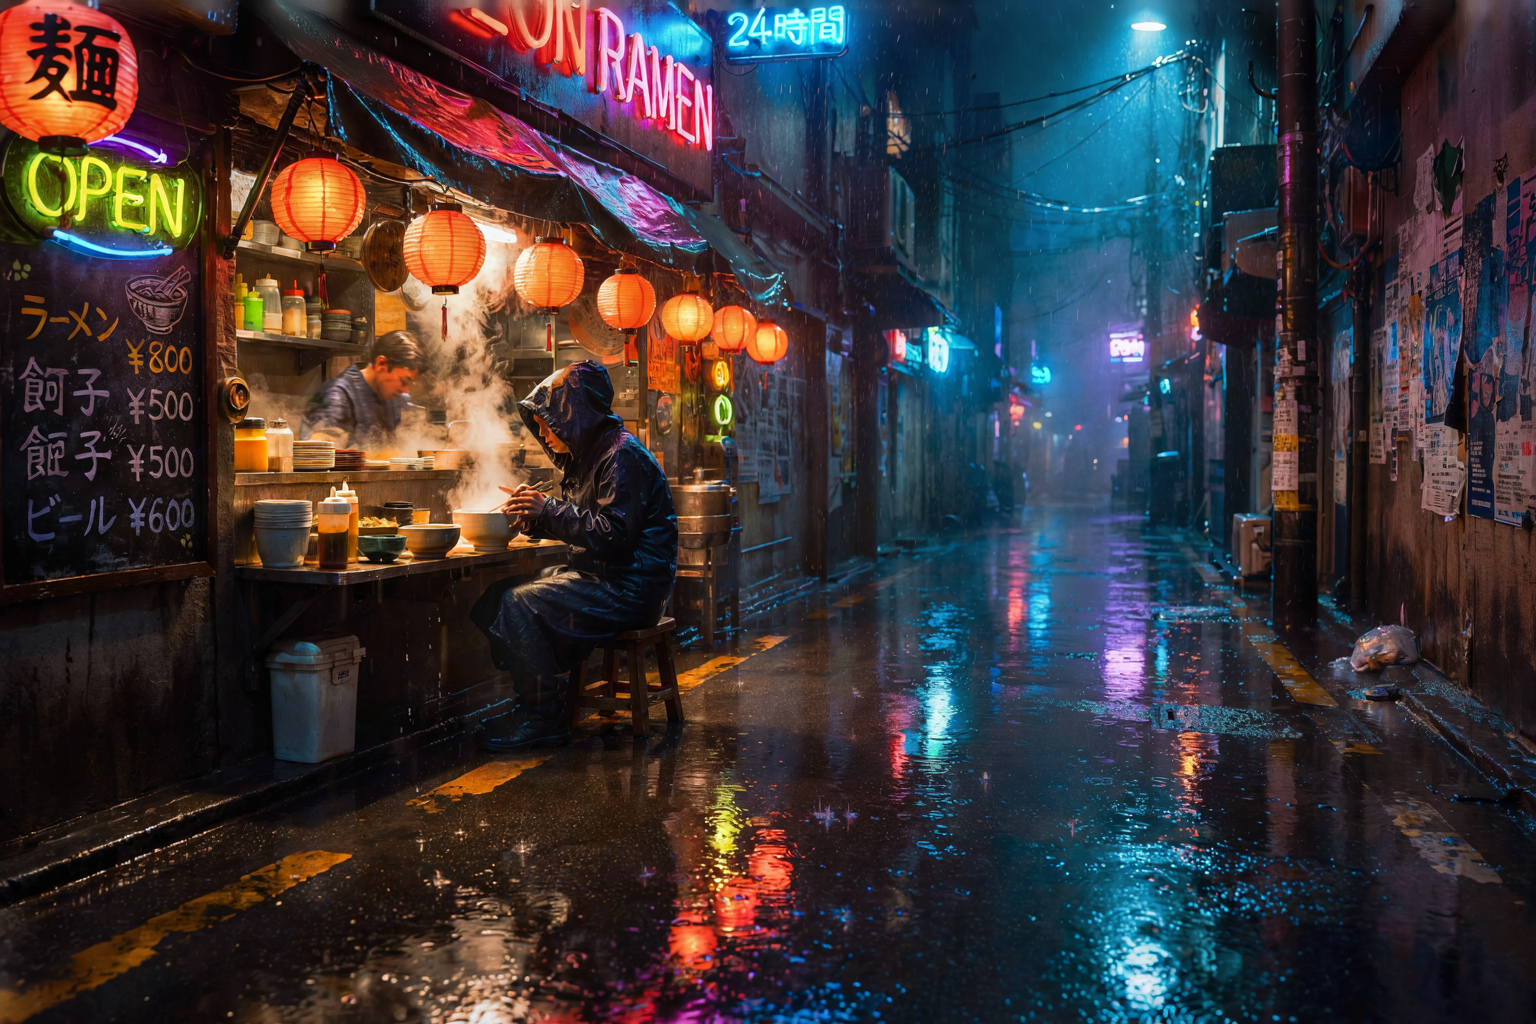

In [12]:
# ── Generate the Neon Ramen Alley (local GPU inference) ───────────────────────
# Adjust the preset slider above before running this cell.
# V4_QUALITY_48 recommended — the scene has a lot of fine text and neon detail.

ramen_image = generate(
    ramen_prompt,
    output_path='neon_ramen_alley.png',
    width=1536,
    height=1024,
)


## Memory Usage

Shows how much VRAM (GPU) and RAM (system) the loaded model occupies.
Call `show_memory()` any time — after loading, after generating, or to spot leaks.


In [13]:
import psutil
from IPython.display import display, HTML


def _bar(used: float, total: float, color: str, label: str) -> str:
    """Return one HTML progress-bar row."""
    pct = min(used / total * 100, 100) if total > 0 else 0
    warn = ' color:#ff6b6b;' if pct > 85 else ''
    return f"""
    <div style="margin:8px 0">
      <div style="display:flex; justify-content:space-between; font-size:13px;
                  font-family:monospace; margin-bottom:3px">
        <span style="font-weight:600">{label}</span>
        <span style="{warn}">{used:.2f} GB / {total:.2f} GB &nbsp;({pct:.1f}%)</span>
      </div>
      <div style="background:#2a2a2a; border-radius:6px; height:18px; overflow:hidden">
        <div style="width:{pct:.1f}%; height:100%;
                    background:linear-gradient(90deg,{color});
                    border-radius:6px; transition:width .3s ease"></div>
      </div>
    </div>"""


def show_memory():
    """Render a fancy VRAM + RAM usage panel inline in the notebook."""
    rows = []

    # ── VRAM (CUDA only) ──────────────────────────────────────────────────────
    if DEVICE == 'cuda':
        props      = torch.cuda.get_device_properties(0)
        total_vram = props.total_memory / 1e9
        alloc_vram = torch.cuda.memory_allocated(0) / 1e9
        reserv_vram = torch.cuda.memory_reserved(0) / 1e9
        rows.append(_bar(alloc_vram,  total_vram, '#a855f7,#ec4899', f'VRAM allocated  ({props.name})'))
        rows.append(_bar(reserv_vram, total_vram, '#6366f1,#818cf8', f'VRAM reserved   ({props.name})'))

    # ── System RAM ────────────────────────────────────────────────────────────
    vm        = psutil.virtual_memory()
    proc_rss  = psutil.Process().memory_info().rss / 1e9
    total_ram = vm.total / 1e9
    used_ram  = (vm.total - vm.available) / 1e9
    rows.append(_bar(proc_rss, total_ram, '#10b981,#34d399', 'RAM  this process (RSS)'))
    rows.append(_bar(used_ram, total_ram, '#0ea5e9,#38bdf8',  'RAM  system total used'))

    html = f"""
    <div style="background:#1a1a2e; border:1px solid #333; border-radius:10px;
                padding:16px 20px; max-width:680px; color:#e2e8f0">
      <div style="font-size:15px; font-weight:700; margin-bottom:12px;
                  letter-spacing:.05em; color:#c084fc">⚡ Memory Usage</div>
      {''.join(rows)}
    </div>"""
    display(HTML(html))


show_memory()
